In [1]:
from qpe import *

from time import time

from scipy.stats import unitary_group, gaussian_kde

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

matplotlib.rcParams['font.family']='serif'
matplotlib.rcParams['axes.unicode_minus']=False
matplotlib.rcParams.update({'font.size': 20})
matplotlib.rc('text', usetex=False)
import random
matplotlib.rc('text', usetex=True)

In [2]:
import qpe
from importlib import reload
reload(qpe)
from qpe import *

In [3]:
labels_train = np.linspace(0.001, 0.999, 21)
dms_train=np.array([dm_iso(negSq) for negSq in labels_train])

N_test=13
chunks=np.linspace(0.001,0.985,N_test)
boundary=1/N_test/2
labels_test=np.sort(np.array([0.001]+[random.uniform(chunks[i-1]+boundary/2, chunks[i]-boundary/2) for i in range(1,len(chunks))]+[0.999]))

dms_test=np.array([dm_iso(negSq) for negSq in labels_test])

In [4]:
labels_test_CRB=np.sort(np.array([0.001]+[random.uniform(0.001, 0.999) for i in range(101)]+[0.999]))
dms_test_CRB=np.array([dm_iso(negSq) for negSq in labels_test])

In [5]:
P_symA=(np.eye(16)+swap_matrix(n_qudits=4, q1=0, q2=2, dim=2))/2
P_asymA=(np.eye(16)-swap_matrix(n_qudits=4, q1=0, q2=2, dim=2))/2
P_symB=(np.eye(16)+swap_matrix(n_qudits=4, q1=1, q2=3, dim=2))/2
P_asymB=(np.eye(16)-swap_matrix(n_qudits=4, q1=1, q2=3, dim=2))/2
P1=P_symA@P_symB
P2=P_symA@P_asymB
P3=P_asymA@P_symB
P4=P_asymA@P_asymB
povm=[P1,P2,P3,P4]
P1+P2+P3+P4

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,

In [6]:
def qCRB(negSq):
    #neg=math.sqrt(negSq)
    return (2*negSq*(1-negSq))

In [7]:
QFIs2=[1/qCRB(negSq) for negSq in labels_test_CRB]

In [8]:
def iso_channel(dm=rhoBell, p=0.1):
    return dm_iso(p)

In [9]:
channel_func=iso_channel
dm=rhoBell
channel_args=()
QFIs=[qfi(channel_func, dm, p, channel_args, n_copies=2, n_ext=0, dp=1e-3) for p in labels_test_CRB]

In [10]:
def cfi_eq(negSq):
    N=math.sqrt(negSq)
    top=(2*N+1)**2*(2*N**2+2*N+5)
    bottom=8*N**2*(N**2+N+7)*(2-N**2-N)*(N**2+N+1)
    return top/bottom

In [11]:
CFIs_eq=[cfi_eq(negSq) for negSq in labels_test_CRB]
CFIs=[cfi(dm_iso_negSq_channel, np.eye(2), negSq, channel_args=(), povm=povm, n_copies=2, dp=1e-5) for negSq in labels_test_CRB]

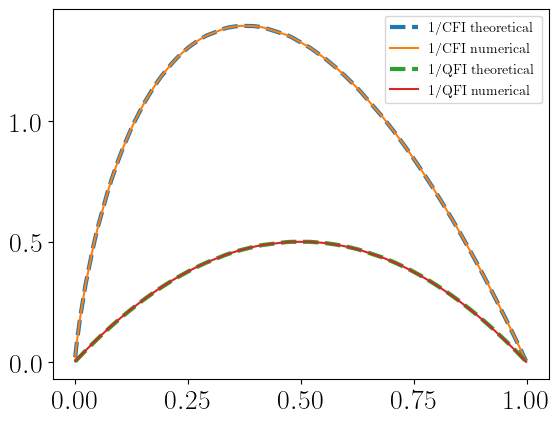

In [12]:
plt.plot(labels_test_CRB, 1/np.array(CFIs_eq), label="1/CFI theoretical",  linestyle='dashed', linewidth=3)
plt.plot(labels_test_CRB, 1/np.array(CFIs), label="1/CFI numerical")
plt.plot(labels_test_CRB, 1/(np.array(QFIs2)), label="1/QFI theoretical",  linestyle='dashed', linewidth=3)
plt.plot(labels_test_CRB,1/np.array(QFIs), label="1/QFI numerical")
plt.legend(fontsize=10)

In [13]:
n_inp = 2
n_train = len(dms_train)#1000
n_test = len(dms_test)#10000
mixed = True
marks = "neg"
eps = 1e-3

In [14]:
def ave_haar(negSq, k):
    neg=math.sqrt(negSq)
    return (14847+44*k *(-7+27*neg*(1+neg)))/(98*(303+22*k))
def var_haar(negSq, k):
    neg=math.sqrt(negSq)
    top=729*k**2*(-13223+2*neg*(1+neg)*(1201+968*neg*(1+neg)))
    bottom=9604*(303+22*k)**2
    return -top/bottom
def var_haar_reduced(negSq, k):
    neg=math.sqrt(negSq)
    top = neg**2*(-13223+2*neg*(1+neg)*(1201+968*neg*(1+neg)))
    bottom = 484*(1+2*neg)**2
    return -top/bottom

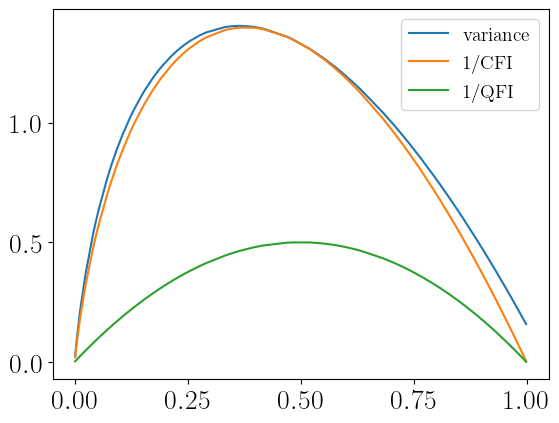

In [15]:
vars_haar=[var_haar_reduced(label, 10) for label in labels_test_CRB]
plt.plot(labels_test_CRB, vars_haar,label="variance")
plt.plot(labels_test_CRB, 1/np.array(CFIs), label="1/CFI")
plt.plot(labels_test_CRB,1/np.array(QFIs), label="1/QFI")
plt.legend(fontsize=14)

In [16]:
n_copies = 2
n_tot = n_inp*n_copies
w_ls = 1e0
w_var = 1e-4
K=w_ls/w_var
method = "BFGS"
options = {"maxiter": int(1e4)}#, "maxfun": int(1e10)}#

### Don't forget to update theoretical values:
labels_test_haar=[ave_haar(negSq, K) for negSq in labels_test]
disps_test_haar=[var_haar(negSq, K) for negSq in labels_test]

In [17]:
ansatz = []
# default case:
ansatz.append(eye(2**n_tot))

# swaps between first pair and second pair
ansatz.append(swap_matrix(n_tot, 0, 2, dim=2))
ansatz.append(swap_matrix(n_tot, 1, 3, dim=2))
ansatz.append(swap_matrix(n_tot, 0, 2, dim=2)@swap_matrix(n_tot, 1, 3, dim=2))

n_pars = len(ansatz)
n_pars

4

In [18]:
dms_train_c = zeros([n_train, 2**n_tot, 2**n_tot], dtype=complex)
for i in range(n_train):
    dms_train_c[i] = reduce(kron, [dms_train[i]]*n_copies)

time_start = time()
Q = zeros((n_train, n_pars))
R = zeros((n_train, n_pars, n_pars))
for i in range(n_train):
    print("Computing Q and R: i=%d" %i, end="\r")
    for j in range(n_pars):
        op_loc = dms_train_c[i]@ansatz[j]
        Q[i][j] = trace(op_loc).real
        for k in range(n_pars):
            R[i][j][k] = trace(op_loc@ansatz[k]).real
time_finish = time() - time_start
print("Computing Q and R: completed in %.2f s" %time_finish, end="\r")

In [19]:
matplotlib.rcParams.update({'font.size': 14})
########### k=10000
w_ls = 1e0
w_var = 1e-4
K=w_ls/w_var

labels_test_haar_10000=[ave_haar(negSq, K) for negSq in labels_test_CRB]
disps_test_haar_10000=[var_haar_reduced(negSq, K) for negSq in labels_test_CRB]

purities_test = [trace(dm@dm).real for dm in dms_test]
fvals, result = train_obs(dms_train, labels_train, ansatz, Q=Q, R=R,
                          n_copies=n_copies, x0=None, method=method, w_ls=w_ls, w_var=w_var, options=options, save_data=False, file_name=None)
pars_10000 = result.x

expecs_test_10000, disps_test_10000, H_10000 = aux_info(dms_test, labels_test, pars_10000, ansatz, n_copies=n_copies, iso=True)
#########################

########### K=100
w_ls = 1e0
w_var = 1e-2
K=w_ls/w_var

labels_test_haar_100=[ave_haar(negSq, K) for negSq in labels_test_CRB]
disps_test_haar_100=[var_haar_reduced(negSq, K) for negSq in labels_test_CRB]

fvals, result = train_obs(dms_train, labels_train, ansatz, Q=Q, R=R,
                          n_copies=n_copies, x0=None, method=method, w_ls=w_ls, w_var=w_var, options=options, save_data=False, file_name=None)
pars_100 = result.x

expecs_test_100, disps_test_100, H_100 = aux_info(dms_test, labels_test, pars_100, ansatz, n_copies=n_copies, iso=True)

#########################

########### K=10
w_ls = 1e0
w_var = 1e-1
K=w_ls/w_var

labels_test_haar_10=[ave_haar(negSq, K) for negSq in labels_test_CRB]
disps_test_haar_10=[var_haar_reduced(negSq, K) for negSq in labels_test_CRB]

fvals, result = train_obs(dms_train, labels_train, ansatz, Q=Q, R=R,
                          n_copies=n_copies, x0=None, method=method, w_ls=w_ls, w_var=w_var, options=options, save_data=False, file_name=None)
pars_10 = result.x

expecs_test_10, disps_test_10, H_10 = aux_info(dms_test, labels_test, pars_10, ansatz, n_copies=n_copies, iso=True)
#########################

########### K=1
w_ls = 1e0
w_var = 1e0
K=w_ls/w_var

labels_test_haar_1=[ave_haar(negSq, K) for negSq in labels_test_CRB]
disps_test_haar_1=[var_haar_reduced(negSq, K) for negSq in labels_test_CRB]

purities_test = [trace(dm@dm).real for dm in dms_test]
fvals, result = train_obs(dms_train, labels_train, ansatz, Q=Q, R=R,
                          n_copies=n_copies, x0=None, method=method, w_ls=w_ls, w_var=w_var, options=options, save_data=False, file_name=None)
pars_1 = result.x

expecs_test_1, disps_test_1, H_1 = aux_info(dms_test, labels_test, pars_1, ansatz, n_copies=n_copies, iso=True)
#########################


21
n_tot 4
n_copies 2
n_inp 2
21	Iteration: 5 | Cost: 0.02672543 | Time passed: 0 s
n_tot 4
n_copies 2
n_inp 2
21	Iteration: 11 | Cost: 0.22870537 | Time passed: 0 s
n_tot 4
n_copies 2
n_inp 2
21	Iteration: 14 | Cost: 1.06068196 | Time passed: 0 s
n_tot 4
n_copies 2
n_inp 2


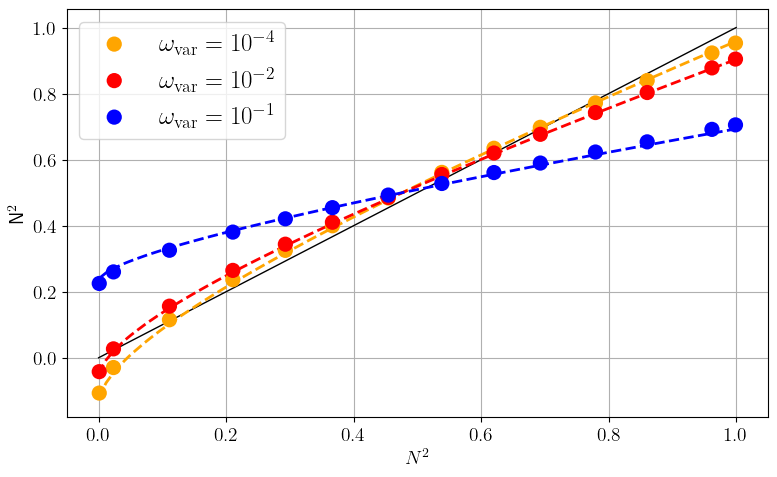

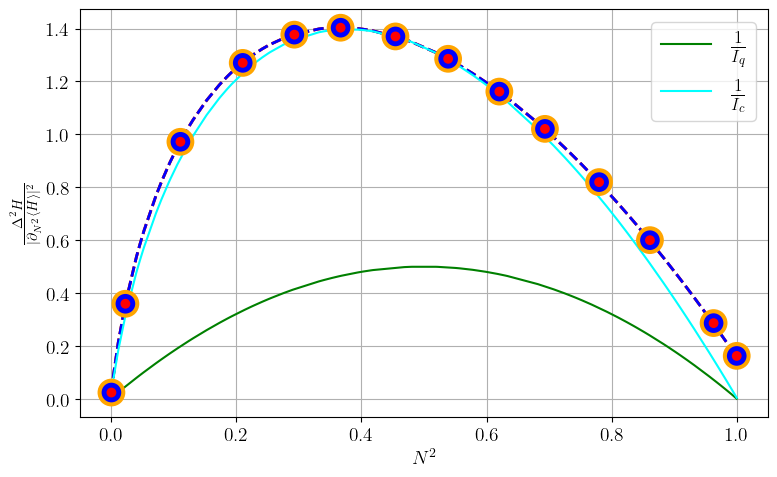

In [20]:
save_plot=['qubits_isoRandom_negSq_2copies_mean_few.pdf', 'qubits_isoRandom_negSq_2copies_var_few.pdf']

cmap_name = "Purples"
cmap = plt.get_cmap(cmap_name)
colors = cmap(np.linspace(0.25, 1., cmap.N))
cmap = LinearSegmentedColormap.from_list(cmap_name, colors)

plt.figure(figsize=(8, 5))
plt.rcParams['axes.axisbelow'] = True
plt.plot(linspace(0, 1), linspace(0, 1), linestyle="-", linewidth=1, color="black")

plt.scatter(labels_test, expecs_test_10000, label="$\omega_{\mathrm{var}}=10^{-4}$", color="orange",  s=120, edgecolor='none', zorder=120) # , color="dodgerblue"
plt.plot(labels_test_CRB, labels_test_haar_10000, color="orange", linestyle='dashed', linewidth=2)

plt.scatter(labels_test, expecs_test_100, label="$\omega_{\mathrm{var}}=10^{-2}$", color="red", s=120, edgecolor='none', zorder=120) # , color="dodgerblue"
plt.plot(labels_test_CRB, labels_test_haar_100, color="red", linestyle='dashed', linewidth=2)

plt.scatter(labels_test, expecs_test_10, label="$\omega_{\mathrm{var}}=10^{-1}$", color="blue", s=120, edgecolor='none', zorder=120) # , color="dodgerblue"
plt.plot(labels_test_CRB, labels_test_haar_10, color="blue", linestyle='dashed', linewidth=2)

plt.xlabel(r"$N^2$")
plt.ylabel(r"$\mathsf{N}^2$")
plt.clim(0.25, 1)
plt.grid()
plt.tight_layout()
plt.legend(loc='upper left', fontsize=18)
plt.savefig(save_plot[0], bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 5))
plt.rcParams['axes.axisbelow'] = True

plt.plot(labels_test_CRB, disps_test_haar_10000, color="orange", linestyle='dashed', linewidth=2)
plt.scatter(labels_test, disps_test_10000, color="orange", s=400, edgecolor='none', zorder=100)

plt.plot(labels_test_CRB, disps_test_haar_100, color="red",  linestyle='dashed', linewidth=2)
plt.scatter(labels_test, disps_test_100, color="red", s=50, edgecolor='none', zorder=110)

plt.plot(labels_test_CRB, disps_test_haar_10, color="blue",  linestyle='dashed', linewidth=2)
plt.scatter(labels_test, disps_test_10, color="blue", s=200, edgecolor='none', zorder=100)

plt.plot(labels_test_CRB, 1/np.array(QFIs), color="green", label=r"$\frac{1}{I_q}$")
plt.plot(labels_test_CRB, 1/np.array(CFIs), color="cyan", label=r"$\frac{1}{I_c}$")

plt.xlabel(r"$N^2$")
plt.ylabel(r"$\frac{\Delta^2 H}{|\partial_{N^2} \langle H\rangle|^2}$")
plt.clim(0.25, 1)
plt.grid()
plt.tight_layout()
plt.legend(fontsize=18)
plt.savefig(save_plot[1], bbox_inches='tight')
plt.show()